<a href="https://colab.research.google.com/github/Arce369/Boston-Housing-prediction-ML/blob/main/notebooks/Lab1_Linear_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# End-to-End Housing Price Prediction Pipeline Using the Boston Housing Dataset

---

## **Objective**
The objective of this analysis is to identify the Ordinary Least Squares (OLS) regression model that achieves the best predictive performance on unseen data. To accomplish this, we systematically explore multiple preprocessing strategies, including feature scaling, feature transformations, and optional logarithmic adjustments to the target variable. We also evaluate different train–test splits and assess model quality through cross‑validated error metrics.

Although classical OLS assumptions are examined, our primary goal is prediction accuracy rather than statistical inference.

## 1. Data: Boston Housing Dataset

The Boston Housing dataset contains information on housing conditions across more than 500 neighborhoods in the Boston metropolitan area. It includes demographic, economic, and environmental variables such as crime rate, property‑tax levels, access to highways, and air pollution measures. The target variable is **MEDV**, the median value of owner‑occupied homes (in \$1000’s).

Although widely used for teaching regression and model diagnostics, the dataset also contains variables that reflect historical racial and socioeconomic biases. Because of these concerns, it is now primarily used for educational purposes and for illustrating fairness and ethical issues in data analysis.

<div align="center">
  
| Column name | Description |
|-------------|-------------|
| **CRIM**    | Per capita crime rate by town |
| **ZN**      | Proportion of residential land zoned for lots over 25,000 sq.ft. |
| **INDUS**   | Proportion of non‑retail business acres per town |
| **CHAS**    | Charles River dummy variable (= 1 if tract bounds river; 0 otherwise) |
| **NOX**     | Nitric oxides concentration (parts per 10 million) |
| **RM**      | Average number of rooms per dwelling |
| **AGE**     | Proportion of owner‑occupied units built prior to 1940 |
| **DIS**     | Weighted distances to five Boston employment centers |
| **RAD**     | Index of accessibility to radial highways |
| **TAX**     | Full‑value property‑tax rate per $10,000 |
| **PTRATIO** | Pupil‑teacher ratio by town |
| **B**       | 1000(Bk − 0.63)² where Bk is the proportion of Black residents by town |
| **LSTAT**   | Percentage of lower‑status population |
| **MEDV**    | Median value of owner‑occupied homes (in \$1000’s) |
  
</div>

##  2. Libraries-environment:
I load the core analytical libraries—NumPy, pandas, and Matplotlib—for data manipulation and visualization.
Additionally, I incorporate key statistical tools from statsmodels (including VIF and anova_lm) to support model diagnostics and goodness‑of‑fit assessment.




In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns

import statsmodels.api as sm
from statsmodels.stats.anova import anova_lm
from statsmodels.stats.stattools import durbin_watson
from statsmodels.stats.diagnostic import het_breuschpagan, normal_ad
from statsmodels.stats.outliers_influence \
      import variance_inflation_factor as VIF



from scipy.stats import shapiro, boxcox,anderson


from sklearn.model_selection import train_test_split, KFold
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import mean_squared_error



In [2]:
!pip install ISLP -q
from ISLP import load_data


## 3. EDA
### *Exploratory Data Analysis (EDA)*

The exploratory analysis of the Boston Housing dataset focuses on understanding the structure, distribution, and relationships within the data before fitting any statistical model. Since the dataset contains demographic, environmental, and economic variables describing Boston neighborhoods, the EDA stage helps identify the key drivers of housing prices and highlights potential issues that may affect model performance.

The analysis begins with a general inspection of the dataset: checking variable types, summarizing numerical features, and identifying missing values or anomalies. Visualizing the distribution of each predictor helps reveal skewness, outliers, or nonlinear patterns that may require transformation. Correlation analysis is especially important in this dataset because several predictors—such as `RM`, `LSTAT`, `NOX`, and `DIS`—tend to be strongly related to the target variable (`MEDV`) and sometimes to each other, raising concerns about multicollinearity.

Scatterplots and pairwise relationships provide insight into how individual features relate to housing prices. For example, `RM` typically shows a positive association with `MEDV`, while `LSTAT` shows a strong negative relationship. Examining these patterns helps determine whether a linear model is appropriate or whether additional transformations or interaction terms might be needed.

Finally, EDA also highlights fairness and ethical considerations. Variables such as `B` and `LSTAT` encode historical racial and socioeconomic biases, which can influence model behavior and interpretation.


In [3]:
data = load_data("Boston")  # <- target variable = 'medv'

X = data.drop('medv', axis=1)
y = data['medv']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,
                                                    random_state=42)
print("X_train shape: ",X_train.shape)
print("X_test shape: ",X_test.shape,"\n")
print("=="*20)
print(X_train.info())
print("=="*20)
print(X_train.describe().T)
print("=="*20)
print('NA values in X_train: ')
print(X_train.isna().sum())


X_train shape:  (404, 12)
X_test shape:  (102, 12) 

<class 'pandas.core.frame.DataFrame'>
Index: 404 entries, 477 to 102
Data columns (total 12 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   crim     404 non-null    float64
 1   zn       404 non-null    float64
 2   indus    404 non-null    float64
 3   chas     404 non-null    int64  
 4   nox      404 non-null    float64
 5   rm       404 non-null    float64
 6   age      404 non-null    float64
 7   dis      404 non-null    float64
 8   rad      404 non-null    int64  
 9   tax      404 non-null    int64  
 10  ptratio  404 non-null    float64
 11  lstat    404 non-null    float64
dtypes: float64(9), int64(3)
memory usage: 41.0 KB
None
         count        mean         std        min         25%        50%  \
crim     404.0    3.609125    8.875058    0.00906    0.081437    0.26139   
zn       404.0   11.569307   23.152481    0.00000    0.000000    0.00000   
indus    404.0   10.985050   

In [4]:
print(X_train.head())

         crim    zn  indus  chas     nox     rm   age     dis  rad  tax  \
477  15.02340   0.0  18.10     0  0.6140  5.304  97.3  2.1007   24  666   
15    0.62739   0.0   8.14     0  0.5380  5.834  56.5  4.4986    4  307   
332   0.03466  35.0   6.06     0  0.4379  6.031  23.3  6.6407    1  304   
423   7.05042   0.0  18.10     0  0.6140  6.103  85.1  2.0218   24  666   
19    0.72580   0.0   8.14     0  0.5380  5.727  69.5  3.7965    4  307   

     ptratio  lstat  
477     20.2  24.91  
15      21.0   8.47  
332     16.9   7.83  
423     20.2  23.29  
19      21.0  11.28  


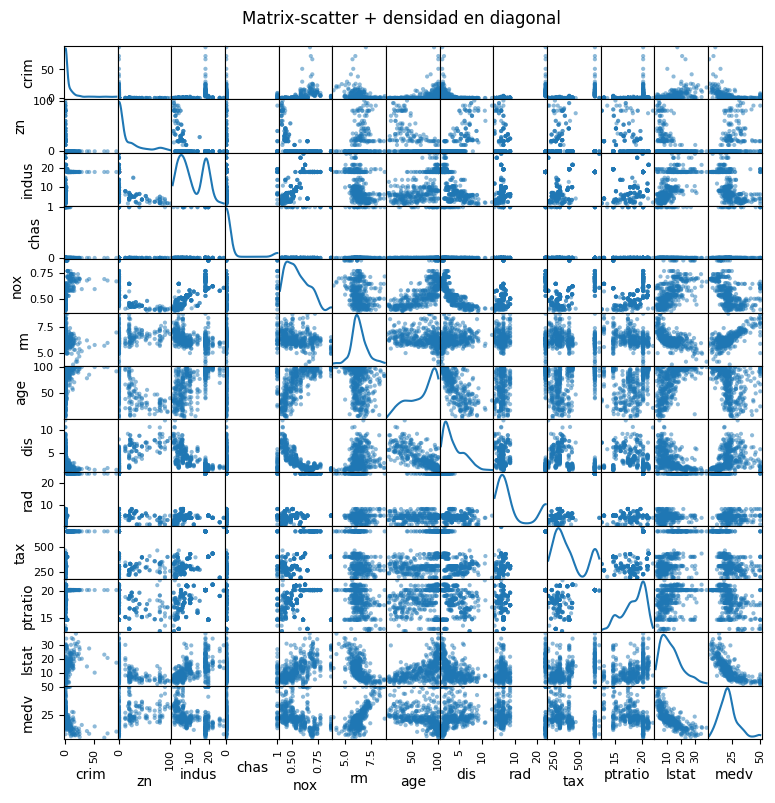

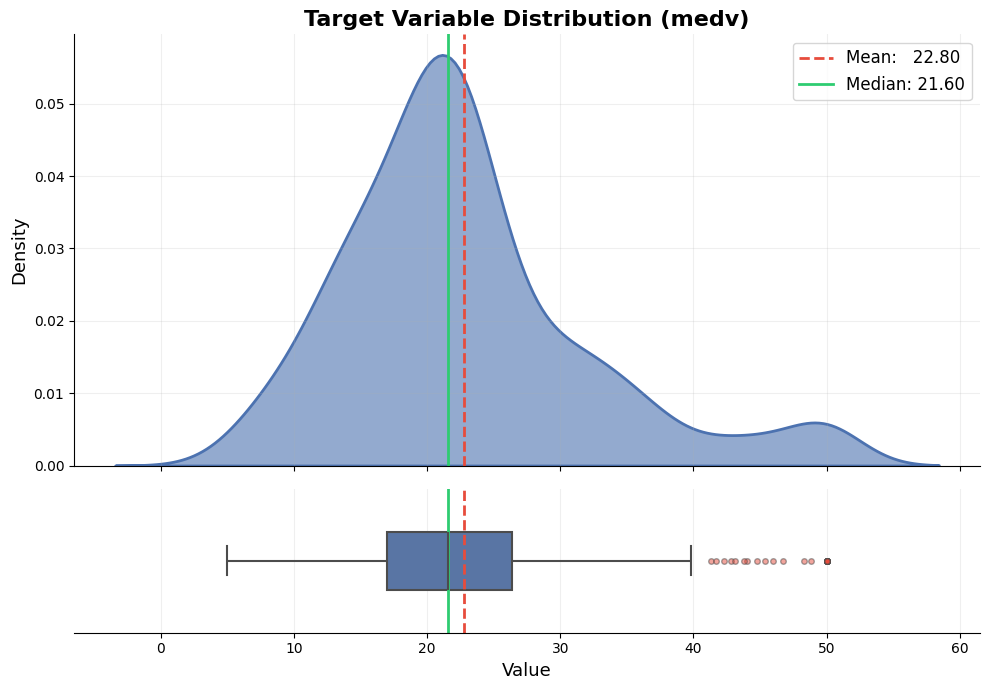

In [5]:
def exploratory_plots(data: pd.DataFrame, y=""):
  #------------------
    num_cols = data.select_dtypes(include=np.number).columns
    pd.plotting.scatter_matrix(data[num_cols], figsize=(9,9), diagonal="kde")
    plt.suptitle("Matrix-scatter + densidad en diagonal", y=0.92)
    plt.show()
    #-------------------------------------------
    fig, (ax1, ax2) = plt.subplots(
    2, 1,
    figsize=(10, 7),
    gridspec_kw={"height_ratios": [3, 1]},
    sharex=True)

    # --- KDE plot (top) ---
    sns.kdeplot(
        data[y],
        fill=True,
        linewidth=2,
        color="#4C72B0",
        alpha=0.6,
        ax=ax1)

    mean_val   = np.mean(data[y])
    median_val = np.median(data[y])

    ax1.axvline(mean_val,   color="#E74C3C", linewidth=2, linestyle="--", label=f"Mean:   {mean_val:.2f}")
    ax1.axvline(median_val, color="#2ECC71", linewidth=2, linestyle="-",  label=f"Median: {median_val:.2f}")

    ax1.set_title(f"Target Variable Distribution ({y})", fontsize=16, weight="bold")
    ax1.set_ylabel("Density", fontsize=13)
    ax1.legend(fontsize=12)
    ax1.grid(alpha=0.2)
    sns.despine(ax=ax1)

    # --- Boxplot (bottom) ---
    sns.boxplot(
        x=data[y],
        ax=ax2,
        color="#4C72B0",
        width=0.4,
        linewidth=1.5,
        flierprops=dict(marker="o", markerfacecolor="#E74C3C", markersize=4, alpha=0.5)
    )

    ax2.axvline(mean_val,   color="#E74C3C", linewidth=2, linestyle="--")
    ax2.axvline(median_val, color="#2ECC71", linewidth=2, linestyle="-")

    ax2.set_xlabel("Value", fontsize=13)
    ax2.set_yticks([])
    ax2.grid(alpha=0.2, axis="x")
    sns.despine(ax=ax2, left=True)

    plt.tight_layout()
    plt.show()

df_plot = X_train.copy()
df_plot['medv'] = y_train

exploratory_plots(df_plot, y='medv')


In [6]:
print("Number of Outliers: \n",df_plot[(df_plot.medv>=40)].shape[0])
print("Training size: \n", X_train.shape[0])
print(f"Percentage of outliers:\n {df_plot[df_plot.medv >= 40].shape[0] / X_train.shape[0] * 100:.2f}%")

Number of Outliers: 
 26
Training size: 
 404
Percentage of outliers:
 6.44%


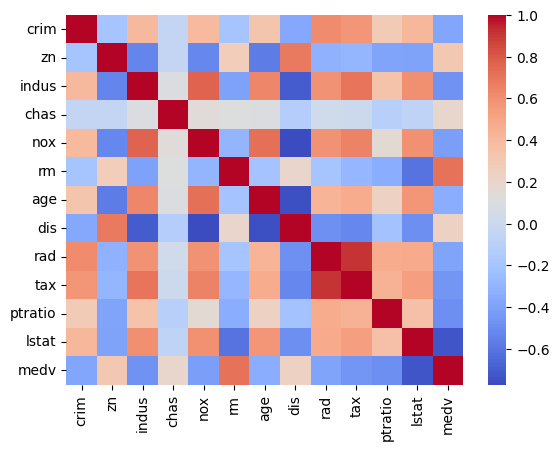

In [7]:
sns.heatmap(df_plot.corr(), annot=False, cmap='coolwarm')
plt.show()

###  Statistical Analysis Findings

Based on the **pairplot** and the **heatmap**, our predictor variables exhibit several key relationships:

#### **1. Correlation with Target Variable**

* Several predictors show an **inverse linear correlation** with the target variable.
* Specifically, **`lstat`** displays a clear **non-linear correlation**, forming a distinct curve rather than a straight line.
* Some variables appear to have no significant correlation with the response variable, most notably the dummy variable **`chas`**.

#### **2. Suspected Multicollinearity**

We can suspect potential **multicollinearity** in the following cases, where predictors are too closely related to each other:

* `rad` and `tax`: These show an extremely high positive correlation.
* `dis` and `age`: These variables exhibit a strong inverse correlation.
* `indus` and `zn`: These also show a high inverse correlation.
* `dis` and `nox`: These show a significant inverse correlation as well.

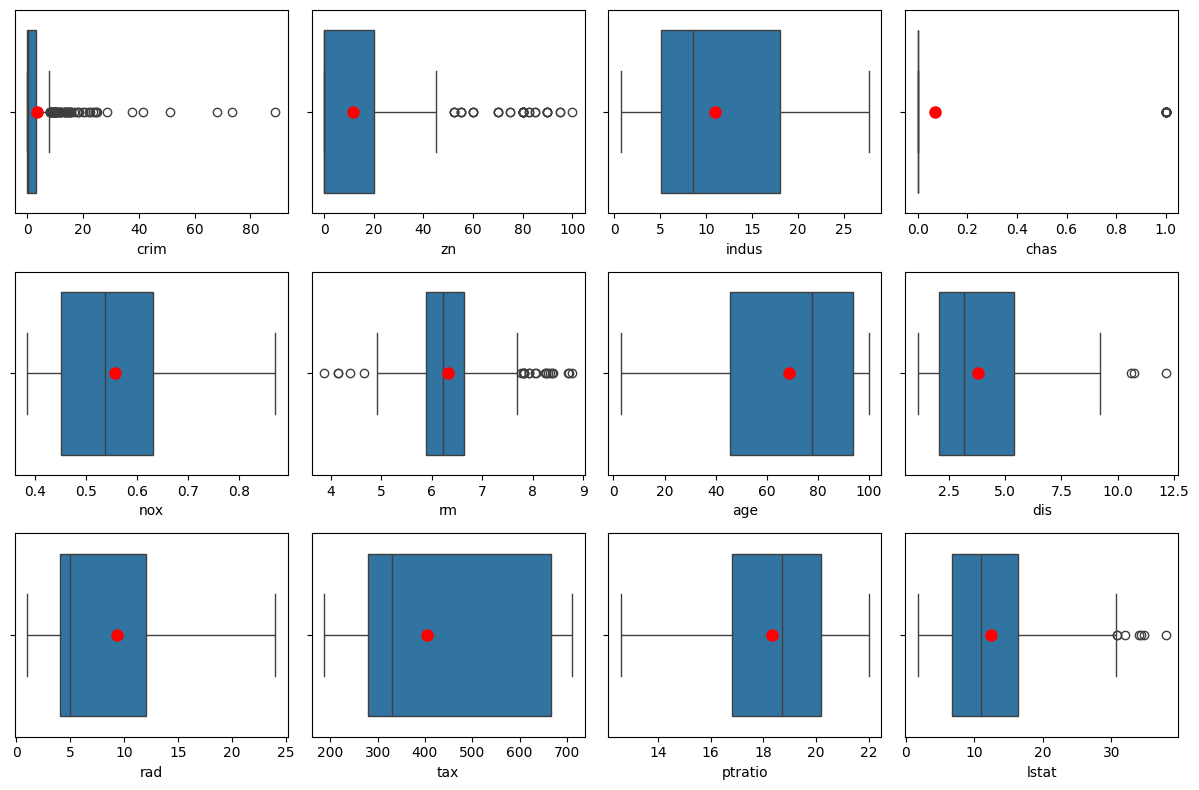

In [8]:
fig, axes = plt.subplots(3, 4, figsize=(12, 8))
for i, ax in enumerate(axes.flatten()):
    sns.boxplot(data=df_plot, x=df_plot.columns[i], ax=ax,showmeans=True,
                        meanprops={'marker':'o',"markerfacecolor":"red",
                                    "markeredgecolor":"red",
                                    "markersize":"8"})
    ax.set_xlabel(df_plot.columns[i])

plt.tight_layout()
plt.show()

### Univariate Analysis: Boxplots & Outlier Detection

This visualization provides a detailed look at the distribution, central tendency, and outliers for each feature in the dataset. The **red dots** represent the **mean**, while the **internal vertical lines** represent the **median**.

#### **1. Skewness (Mean vs. Median)**

The relative position of the mean to the median reveals the directional bias of the data:

* **Positive Skew (Right-Skewed):** Variables such as `crim`, `zn`, `dis`, `rad`, `tax`, and `lstat` show the mean to the right of the median. This confirms that a few high-value observations are pulling the average upward, consistent with the long tails seen in previous histograms.
* **Negative Skew (Left-Skewed):** `age` and `ptratio` show the mean to the left of the median, indicating a concentration of data toward the higher end of the scale.
* **Symmetrical Distribution:** The variable **`rm`** (rooms) shows the mean and median almost perfectly aligned, suggesting a near-normal distribution.

#### **2. Outlier Identification**

The black circles indicate observations that fall significantly outside the typical range (1.5 * IQR):

* **`crim` (Crime Rate):** Contains the most extreme outliers in the dataset. A small number of neighborhoods have crime rates vastly higher than the Boston average.
* **`rm` (Rooms):** Shows outliers on **both ends** of the spectrum. This indicates the presence of both exceptionally small housing units and very large luxury mansions.
* **`lstat` & `dis`:** Both features show significant outliers on the upper tail, representing specific geographic or socioeconomic pockets that deviate from the norm.
* **`chas`:** Since this is a dummy variable, the observations at "1" are flagged as outliers because the vast majority of properties are not adjacent to the Charles River.

#### **3. Dispersion and Variance**

* **High Variability:** `tax`, `age`, and `indus` exhibit wide boxes and long whiskers, indicating that these features vary significantly across different suburbs.
* **Concentrated Data:** `nox` and `ptratio` show tighter distributions, suggesting these environmental and policy-based factors are more uniform across the sampled areas.

---

### Data Preprocessing Implications

Based on this analysis, before training a model I will consider the following transformations:

1. **Box-cox:** Due to the heavy outliers in `crim`, a `Box-cox` tranformation may be more effective than a standard `RobustScaler` or `StandardScaler`.
2. **Non-linear Transformations:** The skewness in `lstat` and `rm` suggests that applying a **Log** or **Square Root transformation** could help linearize their relationship with the target variable, `medv`.



### Summary

#### 1. Target Variable (`medv`) Analysis

* **Distribution:** The target is **right-skewed**, with a mean of **22.80** and a median of **21.60**.
* **Artificial Capping:** Data is heavily **censored at 50**, appearing as a horizontal line in scatter plots and a distinct spike in the density function.
* **Outliers:** Significant upper-bound outliers exist, representing premium properties that deviate from the general market trend.

#### 2. Key Feature Insights

* **Primary Positive Driver (`rm`):** Shows a strong, **linear positive correlation** with price.
* **Primary Negative Driver (`lstat`):** Exhibits a strong **non-linear inverse relationship**. The curved shape suggests that local socioeconomic status impacts prices exponentially rather than linearly.
* **Low Impact Variable:** The dummy variable **`chas`** shows minimal correlation with price, indicating proximity to the river is a secondary factor in this dataset.

---

### Proposed Modeling Strategy

1. **Transformations:** Apply **Log-transform** to `medv`,`lstat` and `rm` to normalize the distribution, handle non-linearity and check outliers.
2. **Data Cleaning:** Evaluate removing observations where **`medv >= 50`** to eliminate the artificial ceiling bias that distorts the price-feature relationship.
3. **Scaling:** Utilize **`Box-cox`** for features with high outlier counts, such as `crim` and `zn` to ensure they don't dominate the model's cost function.


### Suggestions for Preprocessing

The following transformations and feature selections are based on the previous EDA:

1. **Transformations:**  **Log-transform** to `medv`,`lstat` and `rm` to normalize the distribution, handle non-linearity and check outliers.
2. **Feature Selection:** Drop **`rad`** to address multicollinearity issues identified by VIF scores and heatmaps.
3. **Data Cleaning:** Remove observations where **`medv >= 40`** to eliminate the artificial ceiling bias.
4. **Scaling:** Utilize **`Box-cox`** for features with high outlier counts (`zn`, `crim`) to prevent model distortion.

## 4. Metrics and Goodness of Fit

### Regression Metrics

- **1. Mean Absolute Percentage Error (MAPE)**
measures the average percentage error between predictions and true values. It is highly useful for business reporting because its percentage-based output is easy for non-technical audiences to understand, although it can be overly sensitive when true values are close to zero.

$$MAPE = \frac{100}{n} \sum \left| \frac{y - \hat{y}}{y} \right|$$


- **2. Mean Squared Error (MSE)**
computes the average squared difference between predicted and actual values. It is particularly useful during model training and hyperparameter tuning because it strongly penalizes large errors and provides smooth gradients for optimization algorithms.

$$MSE = \frac{1}{n} \sum (y - \hat{y})^2$$


- **3. Root Mean Squared Error (RMSE)**
is the square root of the MSE, returning the error metric to the same units as the target variable. It is broadly useful for general regression performance evaluation because it remains sensitive to large deviations while being much more interpretable than raw squared errors.

$$RMSE = \sqrt{MSE}$$

- **4. Coefficient of Determination (R²)**
measures the proportion of variance in the target variable that is explained by the model's predictors. It is useful for quickly assessing the overall fit of a model, where a score closer to 1.0 indicates a stronger explanatory power.

$$R^2 = 1 - \frac{SS_{res}}{SS_{tot}}$$

-  **5. Adjusted R²**
modifies the standard $R^2$ by penalizing the addition of irrelevant predictors to the model. It is essential for feature selection and comparing models with different numbers of variables, ensuring that a model's score only increases if a new feature genuinely improves its predictive power.

$$R^2_{adj} = 1 - (1 - R^2)\frac{n - 1}{n - p - 1}$$

---

### Goodness of Fit Diagnostics

Beyond metrics, regression models must satisfy key statistical assumptions. The following diagnostics evaluate those assumptions.


-  1. **Normality of Residuals (Shapiro–Wilk, Anderson–Darling)**
These tests evaluate whether the model's residuals follow a normal distribution, typically requiring a p-value > 0.05 to accept normality. This is critical because normal residuals are a core assumption required to calculate valid confidence intervals and perform reliable hypothesis testing, such as t-tests and F-tests.



- 2. **Global ANOVA (F-Test)**
The F-Test evaluates the global statistical significance of the regression model by testing the null hypothesis that all regression coefficients are zero. It is useful for determining right away if the model is statistically meaningful (p-value < 0.05) and actually explains variance in the target better than a simple baseline mean.



-  3. **Breusch–Pagan Test (Homoscedasticity)**
This test checks whether the residuals exhibit constant variance across all levels of the independent variables, aiming for a p-value > 0.05 to confirm homoscedasticity. It is vital because detecting heteroscedasticity (non-constant variance) indicates that the standard errors of the coefficients are biased, which invalidates the statistical significance of your predictors.



-  4. **Durbin–Watson Test (Independence of Residuals)**
The Durbin-Watson statistic measures the presence of autocorrelation in the residuals, with values between 1.5 and 2.5 generally indicating independence. It is highly useful in time-series or sequential data because unchecked autocorrelation violates the independence assumption of linear regression, leading to biased parameter estimates and artificially narrow confidence intervals.



-  5. **Variance Inflation Factor (VIF)**
VIF assesses the degree of multicollinearity among the predictors by measuring how much the variance of an estimated regression coefficient is inflated due to correlations with other independent variables. It is crucial for ensuring the stability and interpretability of the model, as high VIF values (typically > 5) indicate that features are redundantly explaining the same variance, which destabilizes the coefficients.

---

## Summary

<div align="center">

| Component | What it Evaluates | Why it Matters |
|----------|-------------------|----------------|
| **MAPE** | Percentage error | Business interpretability |
| **MSE / RMSE** | Magnitude of prediction error | Penalizes large deviations |
| **R² / Adjusted R²** | Variance explained | Model comparison |
| **Normality tests** | Distribution of residuals | Valid inference |
| **ANOVA F-test** | Global model significance | Determines usefulness |
| **Breusch–Pagan** | Constant variance | Valid standard errors |
| **Durbin–Watson** | Autocorrelation | Independence assumption |
| **VIF** | Multicollinearity | Stability of coefficients |
</div>

In [9]:
def mape(y_true, y_pred):
    y_true = np.asarray(y_true); y_pred = np.asarray(y_pred)
    eps = 1e-12
    return np.mean(np.abs((y_true - y_pred) / np.maximum(np.abs(y_true), eps))) * 100

def mse(y_true, y_pred):
    return float(np.mean((np.asarray(y_true) - np.asarray(y_pred))**2))

def rmse(y_true, y_pred):
    return float(np.sqrt(mse(y_true, y_pred)))

def r2(y_true, y_pred):
    ss_res = np.sum((y_true - y_pred)**2)
    ss_tot = np.sum((y_true - np.mean(y_true))**2)
    return 1-ss_res/ss_tot

def adjusted_r2(r2, n, p):
    return 1 - (1 - r2) * (n - 1) / max(n - p - 1, 1)

def compute_vif_from_design(exog_df: pd.DataFrame) -> pd.DataFrame:
    X = exog_df.copy()
    if "Intercept" in X.columns:
        X = X.drop(columns=["Intercept"])
    const_cols = [c for c in X.columns if np.isclose(X[c].var(ddof=0), 0)]
    X = X.drop(columns=const_cols, errors="ignore")

    vifs = []
    for i, col in enumerate(X.columns):
        vifs.append((col, VIF(X.values, i)))
    return pd.DataFrame(vifs, columns=["variable", "VIF"]).sort_values("VIF", ascending=False)


def run_diagnostics(results, X_sm, y_true):
    residuals = y_true - results.predict(X_sm)
    diagnostics = {}

    # a) Shapiro-Wilk & Anderson-Darling — normality
    stat_sw, p_sw = shapiro(residuals)
    ad_result     = anderson(residuals, dist='norm')
    sig_idx_5     = list(ad_result.significance_level).index(5.0)
    ad_crit_5     = ad_result.critical_values[sig_idx_5]

    diagnostics['normality'] = {
        'Shapiro-Wilk': {
            'statistic': stat_sw,
            'p_value':   p_sw,
            'verdict':   "OK - normality accepted" if p_sw > 0.05 else "FAIL - normality rejected"
        },
        'Anderson-Darling': {
            'statistic':          ad_result.statistic,
            'critical_value_5pct': ad_crit_5,
            'verdict':            "OK - normality accepted" if ad_result.statistic < ad_crit_5 else "FAIL - normality rejected"
        }
    }

    # b) Global ANOVA — F-test
    diagnostics['global_anova'] = {
        'test':    'F-Test',
        'f_value': results.fvalue,
        'p_value': results.f_pvalue,
        'verdict': "OK - model globally significant" if results.f_pvalue < 0.05 else "FAIL - model not significant"
    }

    # c) Breusch-Pagan — homoscedasticity
    bp_lm, bp_p, _, _ = het_breuschpagan(residuals, X_sm)
    diagnostics['homoscedasticity'] = {
        'test':         'Breusch-Pagan',
        'lm_statistic': bp_lm,
        'p_value':      bp_p,
        'verdict':      "OK - homoscedasticity" if bp_p > 0.05 else "WARN - heteroscedasticity detected"
    }

    # d) Durbin-Watson — independence
    dw_stat = durbin_watson(residuals)
    diagnostics['independence'] = {
        'test':         'Durbin-Watson',
        'dw_statistic': dw_stat,
        'verdict':      "OK - no autocorrelation" if 1.5 < dw_stat < 2.5 else "WARN - autocorrelation detected"
    }

    # e) VIF — multicollinearity
    vif_df = compute_vif_from_design(X_sm)

    HIGH_VIF   = 10.0
    MEDIUM_VIF = 5.0

    high_vif   = vif_df[vif_df["VIF"] >= HIGH_VIF]["variable"].tolist()
    medium_vif = vif_df[(vif_df["VIF"] >= MEDIUM_VIF) & (vif_df["VIF"] < HIGH_VIF)]["variable"].tolist()

    if high_vif:
        vif_verdict = f"FAIL - severe multicollinearity in: {high_vif}"
    elif medium_vif:
        vif_verdict = f"WARN - moderate multicollinearity in: {medium_vif}"
    else:
        vif_verdict = "OK - no multicollinearity detected"

    diagnostics['multicollinearity'] = {
        'test':    'VIF',
        'details': vif_df.set_index("variable")["VIF"].to_dict(),
        'verdict': vif_verdict
    }

    return diagnostics




## 5. Preprocessing `PrepGener class`

### `PrepGener`: Automated Data Preprocessing Pipeline

The `PrepGener` class is an intelligent, transformer designed to automate the data cleaning and feature engineering process. It dynamically analyzes the statistical properties of each column in a DataFrame to apply the most appropriate preprocessing strategy.
|
**Core Functionalities:**

* **Automated Imputation:**
    * Fills missing numerical values using the **median**.
    * Fills missing categorical values using the **mode** (most frequent).
* **Dynamic Numerical Scaling:** Evaluates the distribution of each numerical column (after imputation) to select the best scaler:
    * **Box-Cox / Yeo-Johnson:** Applied if the data is highly skewed (asymmetry > 1.0).
    * **RobustScaler:** Applied if the data has heavy tails/outliers (kurtosis > 1.0).
    * **MinMaxScaler:** Applied if the distribution is highly uniform/flat (kurtosis < -1.0).
    * **StandardScaler:** Applied as the default for roughly normal distributions.
* **Smart Categorical Encoding:** Uses cardinality (number of unique values) to determine the encoding method:
    * **One-Hot Encoding:** Applied to features with unique values below a defined `threshold` (default is 10).
    * **Label Encoding:** Applied to high-cardinality features to avoid dimensionality explosion.
* **Diagnostic Reporting:** Optionally prints a necessity test evaluating magnitude disparities across features and details the chosen strategy for every processed column.
* **Persistence:** Includes built-in `save` and `load` methods via `joblib` to easily serialize the fitted pipeline for production use.

In [10]:
import pandas as pd, numpy as np
import joblib

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import (
    StandardScaler, MinMaxScaler, RobustScaler,
    PowerTransformer, OneHotEncoder, LabelEncoder)

from scipy.stats import kurtosis, skew

class PrepGener:
    def __init__(self, threshold=10, prints=True):
        self.prints = prints
        self.threshold = threshold
        self.scalers = {}
        self.encoders = {}
        self.strategy = {}
        self.num_cols = []
        self.cat_cols = []

        # Inicializamos los imputadores
        self.num_imputer = SimpleImputer(strategy='median')
        self.cat_imputer = SimpleImputer(strategy='most_frequent') # Moda para variables categóricas

    def fit(self, df):
        if self.prints:
          print("\n--- 📝 PREPROCESSING REPORT ---")

        # 1. Identificar tipos de columnas
        self.num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
        self.cat_cols = df.select_dtypes(exclude=[np.number]).columns.tolist()

        # 2. Ajustar imputadores y crear un DataFrame temporal para calcular métricas
        df_temp = df.copy()

        if self.num_cols:
            self.num_imputer.fit(df[self.num_cols])
            df_temp[self.num_cols] = self.num_imputer.transform(df[self.num_cols])
            self.test_scaling_necessity(df_temp[self.num_cols])

        if self.cat_cols:
            self.cat_imputer.fit(df[self.cat_cols])
            df_temp[self.cat_cols] = self.cat_imputer.transform(df[self.cat_cols])

        # 3. Calcular estrategias y ajustar escaladores/codificadores sobre datos SIN nulos
        for col in df_temp.columns:
            if col in self.num_cols:
                col_data = df_temp[col]
                s = skew(col_data)
                k = kurtosis(col_data)
                min_val = col_data.min()

                if abs(s) > 1.0:
                    if min_val > 0:
                        self.strategy[col], self.scalers[col] = 'Box-Cox', PowerTransformer(method='box-cox')
                    else:
                        self.strategy[col], self.scalers[col] = 'Yeo-Johnson', PowerTransformer(method='yeo-johnson')
                elif k > 1.0:
                    self.strategy[col], self.scalers[col] = 'Robust', RobustScaler()
                elif k < -1.0:
                    self.strategy[col], self.scalers[col] = 'MinMax', MinMaxScaler()
                else:
                    self.strategy[col], self.scalers[col] = 'Standard', StandardScaler()

                self.scalers[col].fit(df_temp[[col]])
                if self.prints:
                    print(f"Variable [{col}]: {self.strategy[col]} (Skewness: {s:.2f}, Kurtosis: {k:.2f}, Imputed: Median)")
            else:
                cardinality = df_temp[col].nunique()
                if cardinality < self.threshold:
                    self.strategy[col] = 'OneHot'
                    self.encoders[col] = OneHotEncoder(sparse_output=False, drop='first', handle_unknown='ignore')
                    self.encoders[col].fit(df_temp[[col]])
                    if self.prints:
                      print(f"Variable [{col}]: OneHot (Categories: {cardinality}, Imputed: Mode)")
                else:
                    self.strategy[col] = 'Label'
                    self.encoders[col] = LabelEncoder()
                    self.encoders[col].fit(df_temp[col].astype(str))
                    if self.prints:
                      print(f"Variable [{col}]: Label (Cardinality: {cardinality}, Imputed: Mode)")
        return self

    def test_scaling_necessity(self, df):
        ranges = df.max() - df.min()
        max_range_ratio = ranges.max() / (ranges.min() + 1e-9)
        if self.prints:
          print(f"🔎 NECESSITY TEST: Range Ratio = {max_range_ratio:.2f}")
        if max_range_ratio > 10:
          if self.prints:
            print("⚠️ CRITICAL SCALING: Magnitude disparity greater than 10x.")
        else:
          if self.prints:
            print("✅ RECOMMENDED SCALING: Magnitudes are consistent.")

    def transform(self, df):
        df_out = df.copy()

        # 1. Aplicar Imputación primero
        if self.num_cols:
            df_out[self.num_cols] = self.num_imputer.transform(df_out[self.num_cols])
        if self.cat_cols:
            df_out[self.cat_cols] = self.cat_imputer.transform(df_out[self.cat_cols])

        # 2. Aplicar Escalado y Codificación
        for col, strat in self.strategy.items():
            if strat in ['Standard', 'MinMax', 'Robust', 'Box-Cox', 'Yeo-Johnson']:
                df_out[col] = self.scalers[col].transform(df_out[[col]])

            elif strat == 'OneHot':
                enc = self.encoders[col].transform(df_out[[col]])
                cols_oh = self.encoders[col].get_feature_names_out([col])
                df_out = pd.concat([df_out.drop(col, axis=1), pd.DataFrame(enc, columns=cols_oh, index=df.index)], axis=1)

            elif strat == 'Label':
                df_out[col] = self.encoders[col].transform(df_out[col].astype(str))

        return df_out

    def save(self, f='preprocessor.joblib'):
        joblib.dump(self, f)

    @classmethod
    def load(cls, f='preprocessor.joblib'):
        return joblib.load(f)

## 6. Modeling and Optimization Strategy

Building a robust linear regression model requires more than just minimizing the error; it demands strict adherence to statistical assumptions (like normality and homoscedasticity) and a careful selection of features to prevent overfitting. To achieve this, we will move away from manual trial-and-error and implement a **fully automated, custom iterative pipeline**.

This programmatic approach ensures our experiments are reproducible, systematically evaluated, and statistically sound.

### The Orchestrator: `fix_regression`
At the heart of our strategy is the `fix_regression` function. This orchestrator acts as a grid-search engine tailored specifically for our OLS requirements. It iterates through a predefined grid of preprocessing steps and data-splitting configurations, dynamically training models and evaluating them.

Crucially, it selects the "best" model not just by looking at the lowest Root Mean Squared Error (RMSE), but by applying a **penalized score** if a model violates key statistical assumptions (like failing the Breusch-Pagan or Shapiro-Wilk tests, or having high VIF).

### 🔍 Optimization Search Space
The orchestrator will explore the following parameter space to find the optimal configuration:

* **Train Size (`train_size`):** `[0.60, 0.70, 0.80]`
  * *Purpose:* To evaluate how the volume of training data impacts model stability and out-of-sample generalization.
* **Target Transformation (`y_transform_grid`):** `[None, log]`
  * *Purpose:* To test if a logarithmic transformation on the target variable improves the linearity assumption and the normality of the residuals.
* **Feature Scaling (`x_scale_grid`):** `[None, PrepGener]`
  * *Purpose:* To compare the baseline performance of raw features against the dynamically scaled, imputed, and encoded features processed by our automated `PrepGener` pipeline.

In [11]:
def report( model,
            variables,
            train_df: pd.DataFrame,
            test_df: pd.DataFrame,
            y_train: pd.Series,    #
            y_test: pd.Series,     # careful right here, we should log(y) before using report
            y_log: bool = False,
            prep: bool = False):

    # 1) clone model and add a constant
    model_tr = model
    test = sm.add_constant(test_df[variables], has_constant='add')
    train_df = sm.add_constant(train_df[variables], has_constant='add')

    # 2) predictions
    pred_tr = model_tr.predict()
    pred_te = model_tr.predict(test)

    # 3) original scale
    if y_log:
        y_tr_bt = np.exp(y_train)
        y_te_bt = np.exp(y_test)
        p_tr_bt = np.exp(pred_tr)
        p_te_bt = np.exp(pred_te)
    else:
        y_tr_bt = y_train
        y_te_bt = y_test
        p_tr_bt = pred_tr
        p_te_bt = pred_te

    # 4) metrics

    metrics = {
        "train": {
            "R2": float(model_tr.rsquared),
            "R2_adj": float(model_tr.rsquared_adj),
            "MAPE": float(mape(y_tr_bt, p_tr_bt)),
            "MSE": float(mse(y_tr_bt, p_tr_bt)),
            "RMSE": float(rmse(y_tr_bt, p_tr_bt)),
        },
        "test": {
            "R2": float(r2(y_test,pred_te)),
            "R2_adj": float(adjusted_r2(r2(y_test,pred_te), n=len(y_test), p=len(model_tr.params)-1)),
            "MAPE": float(mape(y_te_bt, p_te_bt)),
            "MSE": float(mse(y_te_bt, p_te_bt)),
            "RMSE": float(rmse(y_te_bt, p_te_bt)),
        }
    }

    # 6) diagnostics on train-fit
    diag = run_diagnostics(model_tr, train_df,y_train)

    # 7) ANOVA (Type II)
    try:
        anova_tbl = anova_lm(model_tr, typ=2)
    except Exception as e:
        anova_tbl = f"ANOVA error: {e}"

    # 8) Tabla de betas (train)
    beta_tbl = pd.DataFrame({
        "beta": model_tr.params,
        "std_err": model_tr.bse,
        "t": model_tr.tvalues,
        "p_value": model_tr.pvalues
    }).sort_values("p_value")

    global_F = {"F": float(model_tr.fvalue), "p_value": float(model_tr.f_pvalue)}

    return {
        "prep": prep,
        "train_model": model_tr,
        "metrics": metrics,
        "diagnostics": diag,
        "anova": anova_tbl,
        "beta_table_train": beta_tbl,
        "global_F_train": global_F,
        "pred": {
            "y_train_true": y_train, "y_train_pred": p_tr_bt,
            "y_test_true": y_test,  "y_test_pred": p_te_bt
        }
    }

def plot_fit_vs_pred(y_true, y_pred, title):

    plt.figure(figsize=(6,6))

    # Scatter
    scatter = plt.scatter(y_true, y_pred, alpha=0.6, label="Model")

    # perfect pred
    lo = min(np.min(y_true), np.min(y_pred))
    hi = max(np.max(y_true), np.max(y_pred))
    ideal_line, = plt.plot([lo, hi], [lo, hi], color="red", label="Perfect prediction")

    plt.xlabel("Actual")
    plt.ylabel("Predicted")
    plt.legend()
    plt.title(title)
    plt.show()


### 6.1 Auxiliary Pipeline Functions

To keep our orchestrator (`fix_regression`) clean and modular, we rely on a set of specialized helper functions. Each function handles a specific phase of the modeling lifecycle, from feature selection to diagnostic reporting.

* **`cv_mse_ols(X, y, cv)`**
  * **Role:** Evaluator.
  * **What it does:** Calculates the K-Fold Cross-Validated Mean Squared Error for a plain OLS model. By using cross-validation rather than a single train/test split, it provides a much more robust and unbiased estimate of how well a specific subset of features will generalize.

* **`backward_stepwise_cv(df_train, y_train, cv_folds)`**
  * **Role:** Feature Selector.
  * **What it does:** Implements a backward elimination algorithm wrapped in cross-validation. It starts with all available features and iteratively drops the variable that results in the most significant improvement (or least degradation) to the CV-MSE. It stops when dropping variables no longer improves the model, ensuring we retain a parsimonious (simple but effective) model.

* **`report(...)`**
  * **Role:** The Diagnostic Engine.
  * **What it does:** Centralizes the calculation of all performance metrics (RMSE, MAPE, $R^2$) and statistical diagnostics (ANOVA, Normality, Homoscedasticity). **Crucially**, if the target variable was log-transformed during training (`y_log=True`), this function applies the inverse transformation (`np.exp()`) to the predictions *before* calculating metrics. This ensures that all models are evaluated on the original scale.

* **`plot_fit_vs_pred(y_true, y_pred, title)`**
  * **Role:** Visual Validator.
  * **What it does:** Generates a scatter plot comparing actual vs. predicted values against a perfect-prediction reference line. It provides an immediate visual cue regarding the model's accuracy and highlights any potential bias or severe outliers in the predictions.

In [12]:
def cv_mse_ols(X: pd.DataFrame, y: pd.Series, cv: int = 3) -> float:
    """
    K-Fold CV MSE for a plain OLS (statsmodels) on the given X, y.
    Both X and y are reset to a 0-based index before splitting
    so KFold positional indices always align.
    """
    X = X.reset_index(drop=True)
    y = pd.Series(np.asarray(y))  # garantiza índice 0-based

    kf = KFold(n_splits=cv, shuffle=True, random_state=42)
    mse_scores = []

    for train_idx, val_idx in kf.split(X):
        X_tr, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_tr, y_val = y.iloc[train_idx], y.iloc[val_idx]

        X_tr_c  = sm.add_constant(X_tr,  has_constant='add')
        X_val_c = sm.add_constant(X_val, has_constant='add')

        model   = sm.OLS(y_tr, X_tr_c).fit()
        preds   = model.predict(X_val_c)
        mse_scores.append(mean_squared_error(y_val, preds))

    return float(np.mean(mse_scores))


def backward_stepwise_cv(
    df_train: pd.DataFrame,
    y_train:  pd.Series,
    cv_folds: int = 3,
    verbose:  bool = True
):
    # ── Normalize indices once, used everywhere below ──
    df_train = df_train.reset_index(drop=True)
    y_train  = pd.Series(np.asarray(y_train))

    remaining     = list(df_train.columns)
    current_score = cv_mse_ols(df_train[remaining], y_train, cv=cv_folds)

    if verbose:
        print(f"\n🔄 Backward Stepwise — {cv_folds}-Fold CV")
        print(f"   Start  │ {len(remaining):>2} vars │ CV-MSE = {current_score:.4f}")
        print(f"   {'─'*55}")

    step = 1
    while len(remaining) > 1:
        best_step_score = np.inf
        worst_feature   = None

        for feat in remaining:
            candidates = [f for f in remaining if f != feat]
            score = cv_mse_ols(df_train[candidates], y_train, cv=cv_folds)
            if score < best_step_score:
                best_step_score = score
                worst_feature   = feat

        if best_step_score < current_score:
            current_score = best_step_score
            remaining.remove(worst_feature)
            if verbose:
                print(f"   Step {step:>2} │ {len(remaining):>2} vars │ CV-MSE = {current_score:.4f}"
                      f"  ✂️  dropped '{worst_feature}'")
            step += 1
        else:
            if verbose:
                print(f"   Step {step:>2} │ No improvement from dropping any variable — STOP")
            break

    # Final model — indices already aligned since both were reset at entry
    X_final     = sm.add_constant(df_train[remaining], has_constant='add')
    final_model = sm.OLS(y_train, X_final).fit()

    if verbose:
        print(f"\n✅ Selected features ({len(remaining)}): {remaining}")
        print(f"   Final CV-MSE: {current_score:.4f} | Train R²: {final_model.rsquared:.4f}\n")

    return final_model, remaining

def fix_regression(
    data: pd.DataFrame,
    target_col: str,
    train_size_grid: tuple = (0.6, 0.7, 0.8),
    do_graphics: bool = True,
    y_transform_grid: tuple = (None, "log"),
    x_scale_grid: tuple = (None, "PrepGener"),
    cv_folds: int = 3,
    seed: int = 42
): #-> Dict[str, Any]:

    if do_graphics:
        exploratory_plots(data,target_col)

    X_full = data.drop(columns=[target_col])
    y_full = data[target_col]

    rows  = []
    store = []

    for tr_size in train_size_grid:
        X_train, X_test, y_train, y_test = train_test_split(
            X_full, y_full, train_size=tr_size, random_state=seed
        )

        for ytr in y_transform_grid:
            for xs in x_scale_grid:

                #  Feature matrix preparation -------------------------------
                if xs == "PrepGener":
                    # Separate binary categorical before scaling
                    cat_train = X_train["chas"].copy()
                    cat_test  = X_test["chas"].copy()

                    X_num_train = X_train.drop(columns=["chas"])
                    X_num_test  = X_test.drop(columns=["chas"])

                    prep = PrepGener(prints=False).fit(X_num_train)
                    X_train_prep = prep.transform(X_num_train)
                    X_test_prep  = prep.transform(X_num_test)

                    X_train_prep["chas"] = cat_train.values
                    X_test_prep["chas"]  = cat_test.values

                    scaled = True
                else:
                    X_train_prep = X_train.copy()
                    X_test_prep  = X_test.copy()
                    scaled = False

                #  Target transformation -------------------------------
                y_train_t = np.log(y_train) if ytr == "log" else y_train

                #  Backward stepwise selection -------------------------------
                final_model, best_features = backward_stepwise_cv(
                    X_train_prep, y_train_t, cv_folds=cv_folds, verbose=False
                )

                #  Report: metrics + diagnostics -------------------------------
                rep = report(
                    final_model,
                    best_features,
                    X_train_prep[best_features],
                    X_test_prep[best_features],
                    y_train_t,
                    y_test,
                    y_log= True if ytr == 'log' else False,
                    prep=scaled
                )

                #  Extract diagnostics (new run_diagnostics() key paths) ─
                rmse_te = rep["metrics"]["test"]["RMSE"]
                rmse_tr = rep["metrics"]["train"]["RMSE"]
                sh_p    = rep["diagnostics"]["normality"]["Shapiro-Wilk"]["p_value"]
                bp_p    = rep["diagnostics"]["homoscedasticity"]["p_value"]
                max_vif = max(rep["diagnostics"]["multicollinearity"]["details"].values())

                #  Penalised score
                penalty  = 0.0
                penalty += 0.10 * rmse_te if bp_p  < 0.05 else 0.0
                penalty += 0.05 * rmse_te if sh_p  < 0.05 else 0.0
                penalty += 0.10 * rmse_te if max_vif > 10  else 0.0
                score = rmse_te + penalty

                # - Store everything needed to reconstruct the best run -
                idx = len(store)
                store.append({
                    "rep":           rep,
                    "model":         final_model,
                    "features":      best_features,
                    "X_train_prep":  X_train_prep,
                    "X_test_prep":   X_test_prep,
                    "y_train_t":     y_train_t,
                    "y_test":        y_test,
                    "ytr":           ytr,
                    "xs":            xs,
                })

                rows.append({
                              "idx":         idx,
                              "train_size":  tr_size,
                              "y_transform": ytr   or "None",
                              "x_scale":     xs    or "None",
                              "features":    best_features,
                              "n_features":  len(best_features),
                              # -- test -------------------------------
                              "RMSE_test":   rmse_te,
                              "MAPE_test":   rep["metrics"]["test"]["MAPE"],
                              "R2_test":     rep["metrics"]["test"]["R2"],
                              "R2adj_test":  rep["metrics"]["test"]["R2_adj"],
                              # -- train -------------------------------                                          # ← new block
                              "RMSE_train":  rmse_tr,
                              "MAPE_train":  rep["metrics"]["train"]["MAPE"],
                              "R2_train":    rep["metrics"]["train"]["R2"],
                              "R2adj_train": rep["metrics"]["train"]["R2_adj"],
                              # -- diagnostics -------------------------------
                              "BP_p":        float(bp_p),
                              "Shapiro_p":   float(sh_p),
                              "VIF_max":     float(max_vif),
                              "score":       float(score),
                          })
    # - Ranking -------------------------------
    ranking  = pd.DataFrame(rows).sort_values("score").reset_index(drop=True)
    best_row = ranking.iloc[0].to_dict()
    best     = store[int(best_row["idx"])]

    print("\n🏆 Best configuration found:")
    print(f"   train_size  : {best_row['train_size']}")
    print(f"   y_transform : {best_row['y_transform']}")
    print(f"   x_scale     : {best_row['x_scale']}")
    print(f"   features    : {best_row['features']}")
    print(f"   RMSE_test   : {best_row['RMSE_test']:.4f}  |  score: {best_row['score']:.4f}")

    if do_graphics:
        plot_fit_vs_pred(
            best["rep"]["pred"]["y_train_true"],
            best["rep"]["pred"]["y_train_pred"],
            "Train: Actual vs Predicted"
        )
        plot_fit_vs_pred(
            best["rep"]["pred"]["y_test_true"],
            best["rep"]["pred"]["y_test_pred"],
            "Test: Actual vs Predicted"
        )

    return {
        "ranking":      ranking,
        "best_config":  best_row,
        "best_report":  best["rep"],
        "best_model":   best["model"],
        "best_features": best["features"],
    }

## 7. Model Search and Execution

In this final stage of the modeling process, we execute the `fix_regression` orchestrator. This function systematically explores the previously defined search space, handling the data splitting, preprocessing, feature selection, and diagnostic testing in a single unified flow.

The execution will provide:
1. **A Performance Ranking:** All model configurations sorted by their **Penalized Score** (balancing predictive power with statistical rigor).
2. **The Winning Configuration:** The specific combination of `train_size`, `y_transformation`, and `X_scaling` that best fits the data.
3. **Comprehensive Diagnostics:** Final validation of the best model's residuals and assumptions to ensure its reliability for inference or prediction.


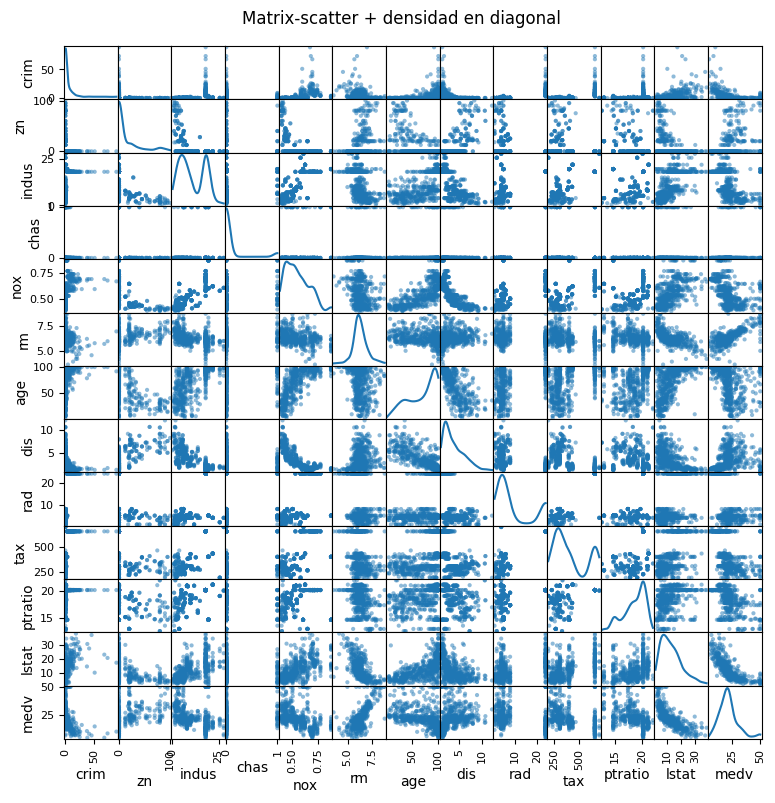

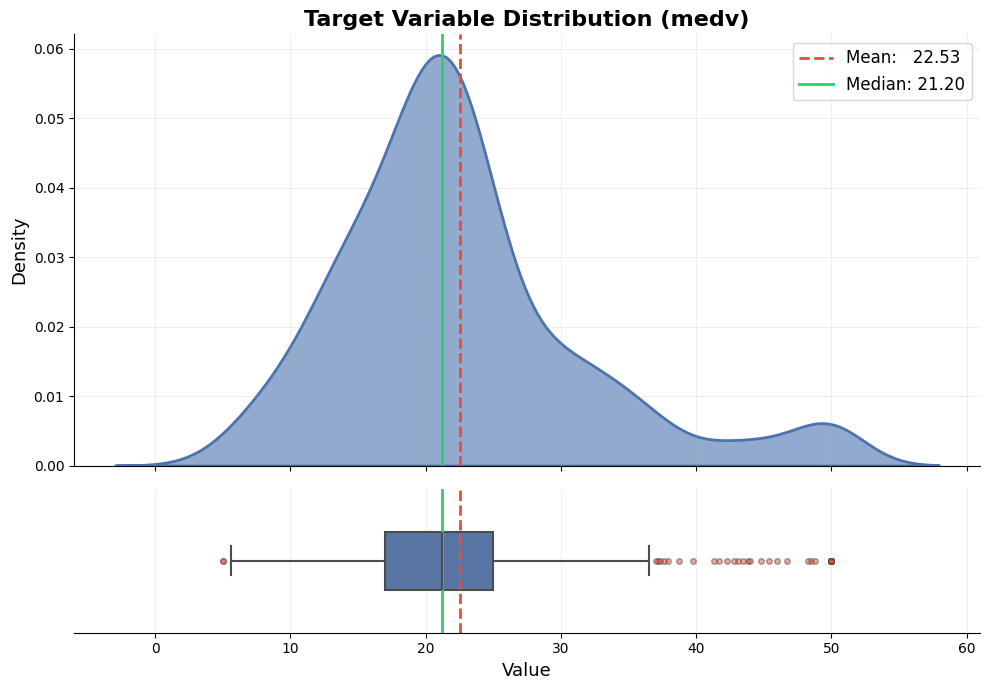


🏆 Best configuration found:
   train_size  : 0.7
   y_transform : None
   x_scale     : PrepGener
   features    : ['nox', 'rm', 'dis', 'ptratio', 'lstat', 'chas']
   RMSE_test   : 4.7798  |  score: 5.4968


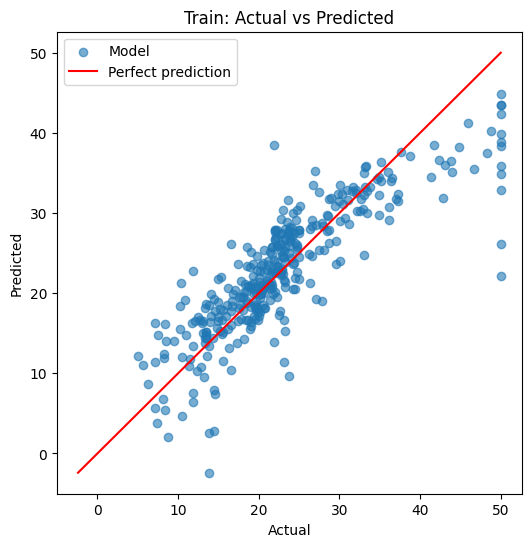

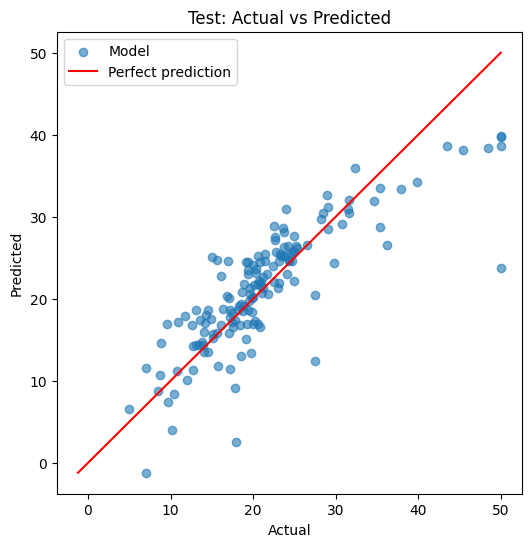


Top 5 models with lower score



,idx,train_size,y_transform,x_scale,features,n_features,RMSE_test,MAPE_test,R2_test,R2adj_test,RMSE_train,MAPE_train,R2_train,R2adj_train,BP_p,Shapiro_p,VIF_max,score
0,5,0.7,None,PrepGener,"[nox, rm, dis, ptratio, lstat, chas]",6,4.779810,16.954391,0.693388,0.680701,4.959623,18.089062,0.720150,0.715311,0.000027,9.299924e-13,3.025284,5.496782
1,1,0.6,None,PrepGener,"[zn, nox, rm, dis, rad, tax, ptratio, lstat, c...",9,4.787511,17.795276,0.698194,0.684120,4.899751,17.554808,0.730937,0.722673,0.000049,7.021484e-12,3.566319,5.505637
2,9,0.8,None,PrepGener,"[zn, nox, rm, dis, ptratio, lstat, chas]",7,4.950331,16.856339,0.665832,0.640948,4.872585,17.930833,0.726705,0.721874,0.000009,3.391847e-13,3.451226,5.692880
3,4,0.7,None,None,"[crim, zn, chas, nox, rm, dis, rad, tax, ptrat...",10,4.570995,16.598455,0.719593,0.699706,4.838323,17.301184,0.733671,0.725907,0.000003,3.477796e-13,71.653499,5.713743
4,0,0.6,None,None,"[crim, zn, chas, nox, rm, dis, rad, tax, ptrat...",10,4.659734,16.952042,0.714089,0.699198,4.833300,17.206613,0.738186,0.729220,0.000097,3.115935e-12,70.227260,5.824668
5,8,0.8,None,None,"[crim, zn, nox, rm, dis, rad, tax, ptratio, ls...",9,4.779343,16.588833,0.688518,0.658047,4.816605,17.478505,0.732948,0.726848,0.000003,5.973308e-15,73.880777,5.974179



Top 5 models with lower RMSE_test



,idx,train_size,y_transform,x_scale,features,n_features,RMSE_test,MAPE_test,R2_test,R2adj_test,RMSE_train,MAPE_train,R2_train,R2adj_train,BP_p,Shapiro_p,VIF_max,score
3,4,0.7,None,None,"[crim, zn, chas, nox, rm, dis, rad, tax, ptrat...",10,4.570995,16.598455,0.719593,0.699706,4.838323,17.301184,0.733671,0.725907,0.000003,3.477796e-13,71.653499,5.713743
4,0,0.6,None,None,"[crim, zn, chas, nox, rm, dis, rad, tax, ptrat...",10,4.659734,16.952042,0.714089,0.699198,4.833300,17.206613,0.738186,0.729220,0.000097,3.115935e-12,70.227260,5.824668
5,8,0.8,None,None,"[crim, zn, nox, rm, dis, rad, tax, ptratio, ls...",9,4.779343,16.588833,0.688518,0.658047,4.816605,17.478505,0.732948,0.726848,0.000003,5.973308e-15,73.880777,5.974179
0,5,0.7,None,PrepGener,"[nox, rm, dis, ptratio, lstat, chas]",6,4.779810,16.954391,0.693388,0.680701,4.959623,18.089062,0.720150,0.715311,0.000027,9.299924e-13,3.025284,5.496782
1,1,0.6,None,PrepGener,"[zn, nox, rm, dis, rad, tax, ptratio, lstat, c...",9,4.787511,17.795276,0.698194,0.684120,4.899751,17.554808,0.730937,0.722673,0.000049,7.021484e-12,3.566319,5.505637


In [13]:
data = load_data("Boston")


results = fix_regression(
    data=data,
    target_col='medv',
    seed=42,
    do_graphics=True,
    cv_folds=5,
)

print('\n','='*50)
print('Top 5 models with lower score')
print('\n','='*50)
display(results['ranking'].head(6))

print('\n','='*50)
print('Top 5 models with lower RMSE_test')
print('\n','='*50)
display(results['ranking'].sort_values(by='RMSE_test').head(5))


In [14]:
print('\n','='*50)
print("Best configuration found:")
results['best_config']


Best configuration found:


{'idx': 5,
 'train_size': 0.7,
 'y_transform': 'None',
 'x_scale': 'PrepGener',
 'features': ['nox', 'rm', 'dis', 'ptratio', 'lstat', 'chas'],
 'n_features': 6,
 'RMSE_test': 4.779810324540496,
 'MAPE_test': 16.95439086292422,
 'R2_test': 0.6933883022243372,
 'R2adj_test': 0.6807009216267236,
 'RMSE_train': 4.959622774336514,
 'MAPE_train': 18.08906152602644,
 'R2_train': 0.7201498372255455,
 'R2adj_train': 0.7153109295118661,
 'BP_p': 2.704899694175551e-05,
 'Shapiro_p': 9.299923552860053e-13,
 'VIF_max': 3.0252844571913786,
 'score': 5.496781873221571}

## 8. Results from modeling

In this section, we discuss the final model that achieved the best performance according to our custom score. The model was generated using the fix_regression() function. Although checking the classical OLS assumptions is not our primary objective—since our focus is predictive performance—we still examine them to determine whether the selected model could also be used for statistical inference (i.e., interpreting coefficients or parameters). The complete diagnostic summary is produced through the report() function.

In [15]:
report = results['best_report']

# ============================================================
# 1. show tables
# ============================================================
print("=== Coefficients Table (beta_table_train) ===")
display(report['beta_table_train'])


# ============================================================
# 2. round metrics
# ============================================================
print("\n=== Metrics (rounded to 4 decimals) ===")

metrics_train = pd.DataFrame(report['metrics']['train'], index=["train"]).round(4)
metrics_test  = pd.DataFrame(report['metrics']['test'],  index=["test"]).round(4)

metrics_df = pd.concat([metrics_train, metrics_test])
display(metrics_df)


# ============================================================
# 3. run diagnostics
# ============================================================
print("\n=== Diagnostics ===")

diag = report['diagnostics']

# Normality
print("\n-- Normality Tests --")
for test_name, vals in diag['normality'].items():
    if test_name == 'Shapiro-Wilk':
        print(f"{test_name}: stat={vals['statistic']:.4f}, p={vals['p_value']:.4e}, verdict={vals['verdict']}")
    elif test_name == 'Anderson-Darling':
        print(f"{test_name}: stat={vals['statistic']:.4f}, crit_val_5pct={vals['critical_value_5pct']:.4f}, verdict={vals['verdict']}")

# Global ANOVA (F-test)
print("\n-- Global ANOVA (F-test) --")
ga = diag['global_anova']
print(f"F = {ga['f_value']:.4f}, p = {ga['p_value']:.4e}, verdict = {ga['verdict']}")

# Homoscedasticity
print("\n-- Homoscedasticity (Breusch-Pagan) --")
bp = diag['homoscedasticity']
print(f"LM = {bp['lm_statistic']:.4f}, p = {bp['p_value']:.4e}, verdict = {bp['verdict']}")

# independence
print("\n-- Independence (Durbin-Watson) --")
dw = diag['independence']
print(f"DW = {dw['dw_statistic']:.4f}, verdict = {dw['verdict']}")

# Multicollinearity (VIF)
print("\n-- Multicollinearity (VIF) --")
vif_df = pd.DataFrame.from_dict(diag['multicollinearity']['details'], orient='index', columns=['VIF'])
display(vif_df)


# ============================================================
# 4. ANOVA table
# ============================================================
print("\n=== ANOVA Table ===")
anova_result = report['anova']

if isinstance(anova_result, str):
    print(anova_result)
else:
    display(anova_result)

=== Coefficients Table (beta_table_train) ===


,beta,std_err,t,p_value
const,22.324081,0.280384,79.619775,5.251553e-225
lstat,-4.255627,0.408965,-10.405858,2.984998e-22
rm,3.239038,0.382851,8.460299,7.556584e-16
ptratio,-2.132710,0.293240,-7.272908,2.357309e-12
dis,-2.223249,0.428709,-5.185916,3.660753e-07
nox,-1.904967,0.463216,-4.112484,4.891738e-05
chas,3.953496,1.053035,3.754384,2.036812e-04



=== Metrics (rounded to 4 decimals) ===


,R2,R2_adj,MAPE,MSE,RMSE
train,0.7201,0.7153,18.0891,24.5979,4.9596
test,0.6934,0.6807,16.9544,22.8466,4.7798



=== Diagnostics ===

-- Normality Tests --
Shapiro-Wilk: stat=0.9204, p=9.2999e-13, verdict=FAIL - normality rejected
Anderson-Darling: stat=6.1314, crit_val_5pct=0.7780, verdict=FAIL - normality rejected

-- Global ANOVA (F-test) --
F = 148.8249, p = 8.7782e-93, verdict = OK - model globally significant

-- Homoscedasticity (Breusch-Pagan) --
LM = 30.8523, p = 2.7049e-05, verdict = WARN - heteroscedasticity detected

-- Independence (Durbin-Watson) --
DW = 2.1335, verdict = OK - no autocorrelation

-- Multicollinearity (VIF) --


,VIF
nox,3.025284
dis,2.590023
lstat,2.326429
rm,1.691912
ptratio,1.211107
chas,1.068714



=== ANOVA Table ===
ANOVA error: 'PandasData' object has no attribute 'design_info'



## 📘 **Modeling Summary and Interpretation**

## **Overview**

The goal of this project was to identify the OLS regression model that provides the best predictive performance on unseen data. To achieve this, we evaluated a wide range of model configurations, including different train sizes, feature subsets, preprocessing strategies, and optional transformations of both predictors and the target variable. Every possible combination was tested, and each model was scored using a custom metric that combines out‑of‑sample RMSE with penalties for violations of classical OLS assumptions.

The best configuration found was:

- **train_size:** 0.7  
- **y_transform:** None  
- **x_scale:** PrepGener  
- **features:** `['nox', 'rm', 'dis', 'ptratio', 'lstat', 'chas']`  
- **RMSE_test:** 4.7798  
- **score:** 5.4968  

This model achieves strong predictive accuracy and shows minimal overfitting, with RMSE values for train and test that are close to each other.

---

## **Predictive Performance**

The selected model demonstrates consistent predictive behavior:

- **RMSE_test ≈ 4.78**  
- **R²_test ≈ 0.69**  
- **MAPE_test ≈ 16.95%**

These values are aligned with what is typically expected for the Boston Housing dataset when using linear models. The model generalizes well, and the difference between training and testing errors is small, indicating stable performance.

Even when compared with the top models ranked by RMSE or by the custom score, the chosen configuration remains competitive and balanced, especially considering its lower multicollinearity (VIF_max ≈ 3.02).

---

## **Why Statistical Inference Is Not Appropriate**

Although the model predicts well, it **cannot be used for statistical inference**, such as interpreting coefficients or constructing confidence intervals. This is because several key OLS assumptions are strongly violated:

### **1. Normality of residuals**
- Shapiro–Wilk p-value: **9.3e‑13**  
- Anderson–Darling statistic far above the 5% critical value  

Both tests clearly reject normality.

### **2. Homoscedasticity**
- Breusch–Pagan p-value: **2.7e‑05**  
- Indicates **heteroscedasticity**, meaning the variance of residuals is not constant.

### **3. Independence**
- Durbin–Watson ≈ **2.13**  
- This assumption is satisfied.

### **4. Multicollinearity**
- VIF_max ≈ **3.02**  
- This assumption is also satisfied.

Because normality and homoscedasticity fail, the classical inferential tools of OLS (t‑tests, p‑values, confidence intervals, F‑tests) are **not reliable**. The coefficients may still be useful for prediction, but they cannot be interpreted in a statistically valid way.

---

## **Consistency Despite Assumption Violations**

Even though the model violates some assumptions, its predictive performance remains strong. This is expected because:

- OLS assumptions are required for **inference**, not for **prediction**.  
- The least squares estimator still provides the best linear unbiased prediction under mild conditions.  
- Cross‑validation and out‑of‑sample evaluation ensure that the model is judged by its ability to generalize, not by theoretical assumptions.

In other words:

> **A model can predict well even if it does not satisfy the classical OLS assumptions.  
> Assumptions matter for inference, not for prediction.**

This is exactly what we observe in the results: the model is not suitable for interpreting coefficients, but it is fully valid as a predictive tool.

---

## **Conclusion**

After testing all possible combinations of variables, preprocessing steps, and transformations, the selected OLS model provides the best balance between predictive accuracy and model simplicity. Although it fails some statistical assumptions and therefore cannot be used for inference, it remains a consistent and reliable predictor of housing prices in the Boston dataset.
